In [15]:
# ==========================================================
# Module : COM 763
# Network Intrusion Detection using Machine Learning
# Author: Palitha Kuruvita / 25026175
# ==========================================================


# ==========================================================
# Module 1 : Dataset Loading
# ==========================================================

import pandas as pd
import numpy as np
import os

# Load Dataset

print("=" * 60)
print("Loading Dataset")
print("=" * 60)

FILE_NAME = "data_raw.csv"

if not os.path.exists(FILE_NAME):
    raise FileNotFoundError(
        f"Dataset '{FILE_NAME}' was not found.\n"
        "Please place data.csv in the project directory."
    )

df = pd.read_csv(FILE_NAME)

print("\nDataset Loaded Successfully.\n")


# Display Basic Information

print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# Display First Five Records

print("\n")
print("=" * 60)
print("First Five Records")
print("=" * 60)

print(df.head())

# Dataset Information

print("\n")
print("=" * 60)
print("Dataset Information")
print("=" * 60)

print(df.info())

# Statistical Summary

print("\n")
print("=" * 60)
print("Statistical Summary")
print("=" * 60)

print(df.describe())

# Data Types

print("\n")
print("=" * 60)
print("Column Data Types")
print("=" * 60)

print(df.dtypes)

# Missing Values

print("\n")
print("=" * 60)
print("Missing Values")
print("=" * 60)

missing = df.isnull().sum()

print(missing)

print("\nTotal Missing Values :", missing.sum())

# Duplicate Records

print("\n")
print("=" * 60)
print("Duplicate Records")
print("=" * 60)

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

# Target Variable Distribution


print("\n")
print("=" * 60)
print("Class Distribution")
print("=" * 60)

TARGET_COLUMN = "Label"

if TARGET_COLUMN in df.columns:

    print(df[TARGET_COLUMN].value_counts())

else:

    print(f"Target column '{TARGET_COLUMN}' not found.")
    print("Please update TARGET_COLUMN to match your dataset.")

# Dataset Memory Usage

print("\n")
print("=" * 60)
print("Memory Usage")
print("=" * 60)

memory = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Memory Used : {memory:.2f} MB")

# Unique Values

print("\n")
print("=" * 60)
print("Unique Values Per Column")
print("=" * 60)

print(df.nunique())


# Completion

print("\n")
print("=" * 60)
print("Module 1 Completed Successfully")
print("=" * 60)


Loading Dataset

Dataset Loaded Successfully.

Dataset Shape
Rows    : 288602
Columns : 79


First Five Records
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 22             166                   1   
1              60148              83                   1   
2                123           99947                   1   
3                123           37017                   1   
4                  0       111161336                 147   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            0   
1                        2                            0   
2                        1                           48   
3                        1                           48   
4                        0                            0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       0   
1                             0                       

In [16]:
# ==========================================================
# Re-evaluation of Module 2 : Data Cleaning
# ==========================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("Re-Loading Original Dataset for Re-evaluation")
print("=" * 60)

df_recheck = pd.read_csv("data.csv")

print("Original Dataset Loaded Successfully")
print(f"Initial Shape : {df_recheck.shape}")

# Handle the target column name with leading space
original_label_column = None
for col in df_recheck.columns:
    if col.strip() == 'Label':
        original_label_column = col
        break

if original_label_column is None:
    print("Error: 'Label' column not found in original data. Please ensure it exists.")
else:
    print(f"Class Distribution before any cleaning:\n{df_recheck[original_label_column].value_counts()}\n")

# --- Apply cleaning steps before outlier removal ---

print("Removing Duplicate Records...")
df_recheck = df_recheck.drop_duplicates()
print(f"Shape after duplicate removal : {df_recheck.shape}")

print("Handling Missing Values...")
df_recheck.replace([np.inf, -np.inf], np.nan, inplace=True)
df_recheck = df_recheck.dropna()
print(f"Shape after missing value and infinite value removal : {df_recheck.shape}")

print("Converting Numeric Columns...")
for col in df_recheck.columns:
    try:
        df_recheck[col] = pd.to_numeric(df_recheck[col])
    except:
        pass
print("Numeric conversion completed.")


# --- Check class distribution BEFORE outlier removal ---
if original_label_column is not None:
    print("\n" + "=" * 60)
    print("Class Distribution BEFORE Outlier Removal")
    print("=" * 60)
    print(df_recheck[original_label_column].value_counts())
    print("\n")

# --- Outlier Removal Step ---
print("Removing Outliers using IQR...")
numeric_columns_recheck = df_recheck.select_dtypes(include=np.number).columns

rows_before_outlier = df_recheck.shape[0]

for col in numeric_columns_recheck:
    Q1 = df_recheck[col].quantile(0.25)
    Q3 = df_recheck[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_recheck = df_recheck[
        (df_recheck[col] >= lower) &
        (df_recheck[col] <= upper)
    ]

rows_after_outlier = df_recheck.shape[0]

print(f"Rows Before Outlier Removal : {rows_before_outlier}")
print(f"Rows After Outlier Removal  : {rows_after_outlier}")
print(f"Rows Removed by Outlier Removal: {rows_before_outlier - rows_after_outlier}")

# --- Check class distribution AFTER outlier removal ---
if original_label_column is not None:
    print("\n" + "=" * 60)
    print("Class Distribution AFTER Outlier Removal")
    print("=" * 60)
    print(df_recheck[original_label_column].value_counts())
    print("\n")

# Reset Index
df_recheck.reset_index(drop=True, inplace=True)

print("Re-evaluation Completed.")

Re-Loading Original Dataset for Re-evaluation
Original Dataset Loaded Successfully
Initial Shape : (252790, 79)
Class Distribution before any cleaning:
 Label
BENIGN          252754
Infiltration        36
Name: count, dtype: int64

Removing Duplicate Records...
Shape after duplicate removal : (252790, 79)
Handling Missing Values...
Shape after missing value and infinite value removal : (252790, 79)
Converting Numeric Columns...
Numeric conversion completed.

Class Distribution BEFORE Outlier Removal
 Label
BENIGN          252754
Infiltration        36
Name: count, dtype: int64


Removing Outliers using IQR...
Rows Before Outlier Removal : 252790
Rows After Outlier Removal  : 26855
Rows Removed by Outlier Removal: 225935

Class Distribution AFTER Outlier Removal
 Label
BENIGN    26855
Name: count, dtype: int64


Re-evaluation Completed.


Loading Cleaned Dataset
Dataset Loaded Successfully
(252790, 79)

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252790 entries, 0 to 252789
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             252790 non-null  int64  
 1    Flow Duration                252790 non-null  int64  
 2    Total Fwd Packets            252790 non-null  int64  
 3    Total Backward Packets       252790 non-null  int64  
 4   Total Length of Fwd Packets   252790 non-null  int64  
 5    Total Length of Bwd Packets  252790 non-null  int64  
 6    Fwd Packet Length Max        252790 non-null  int64  
 7    Fwd Packet Length Min        252790 non-null  int64  
 8    Fwd Packet Length Mean       252790 non-null  float64
 9    Fwd Packet Length Std        252790 non-null  float64
 10  Bwd Packet Length Max         252790 non-null  int64  
 11   Bwd Packet Lengt

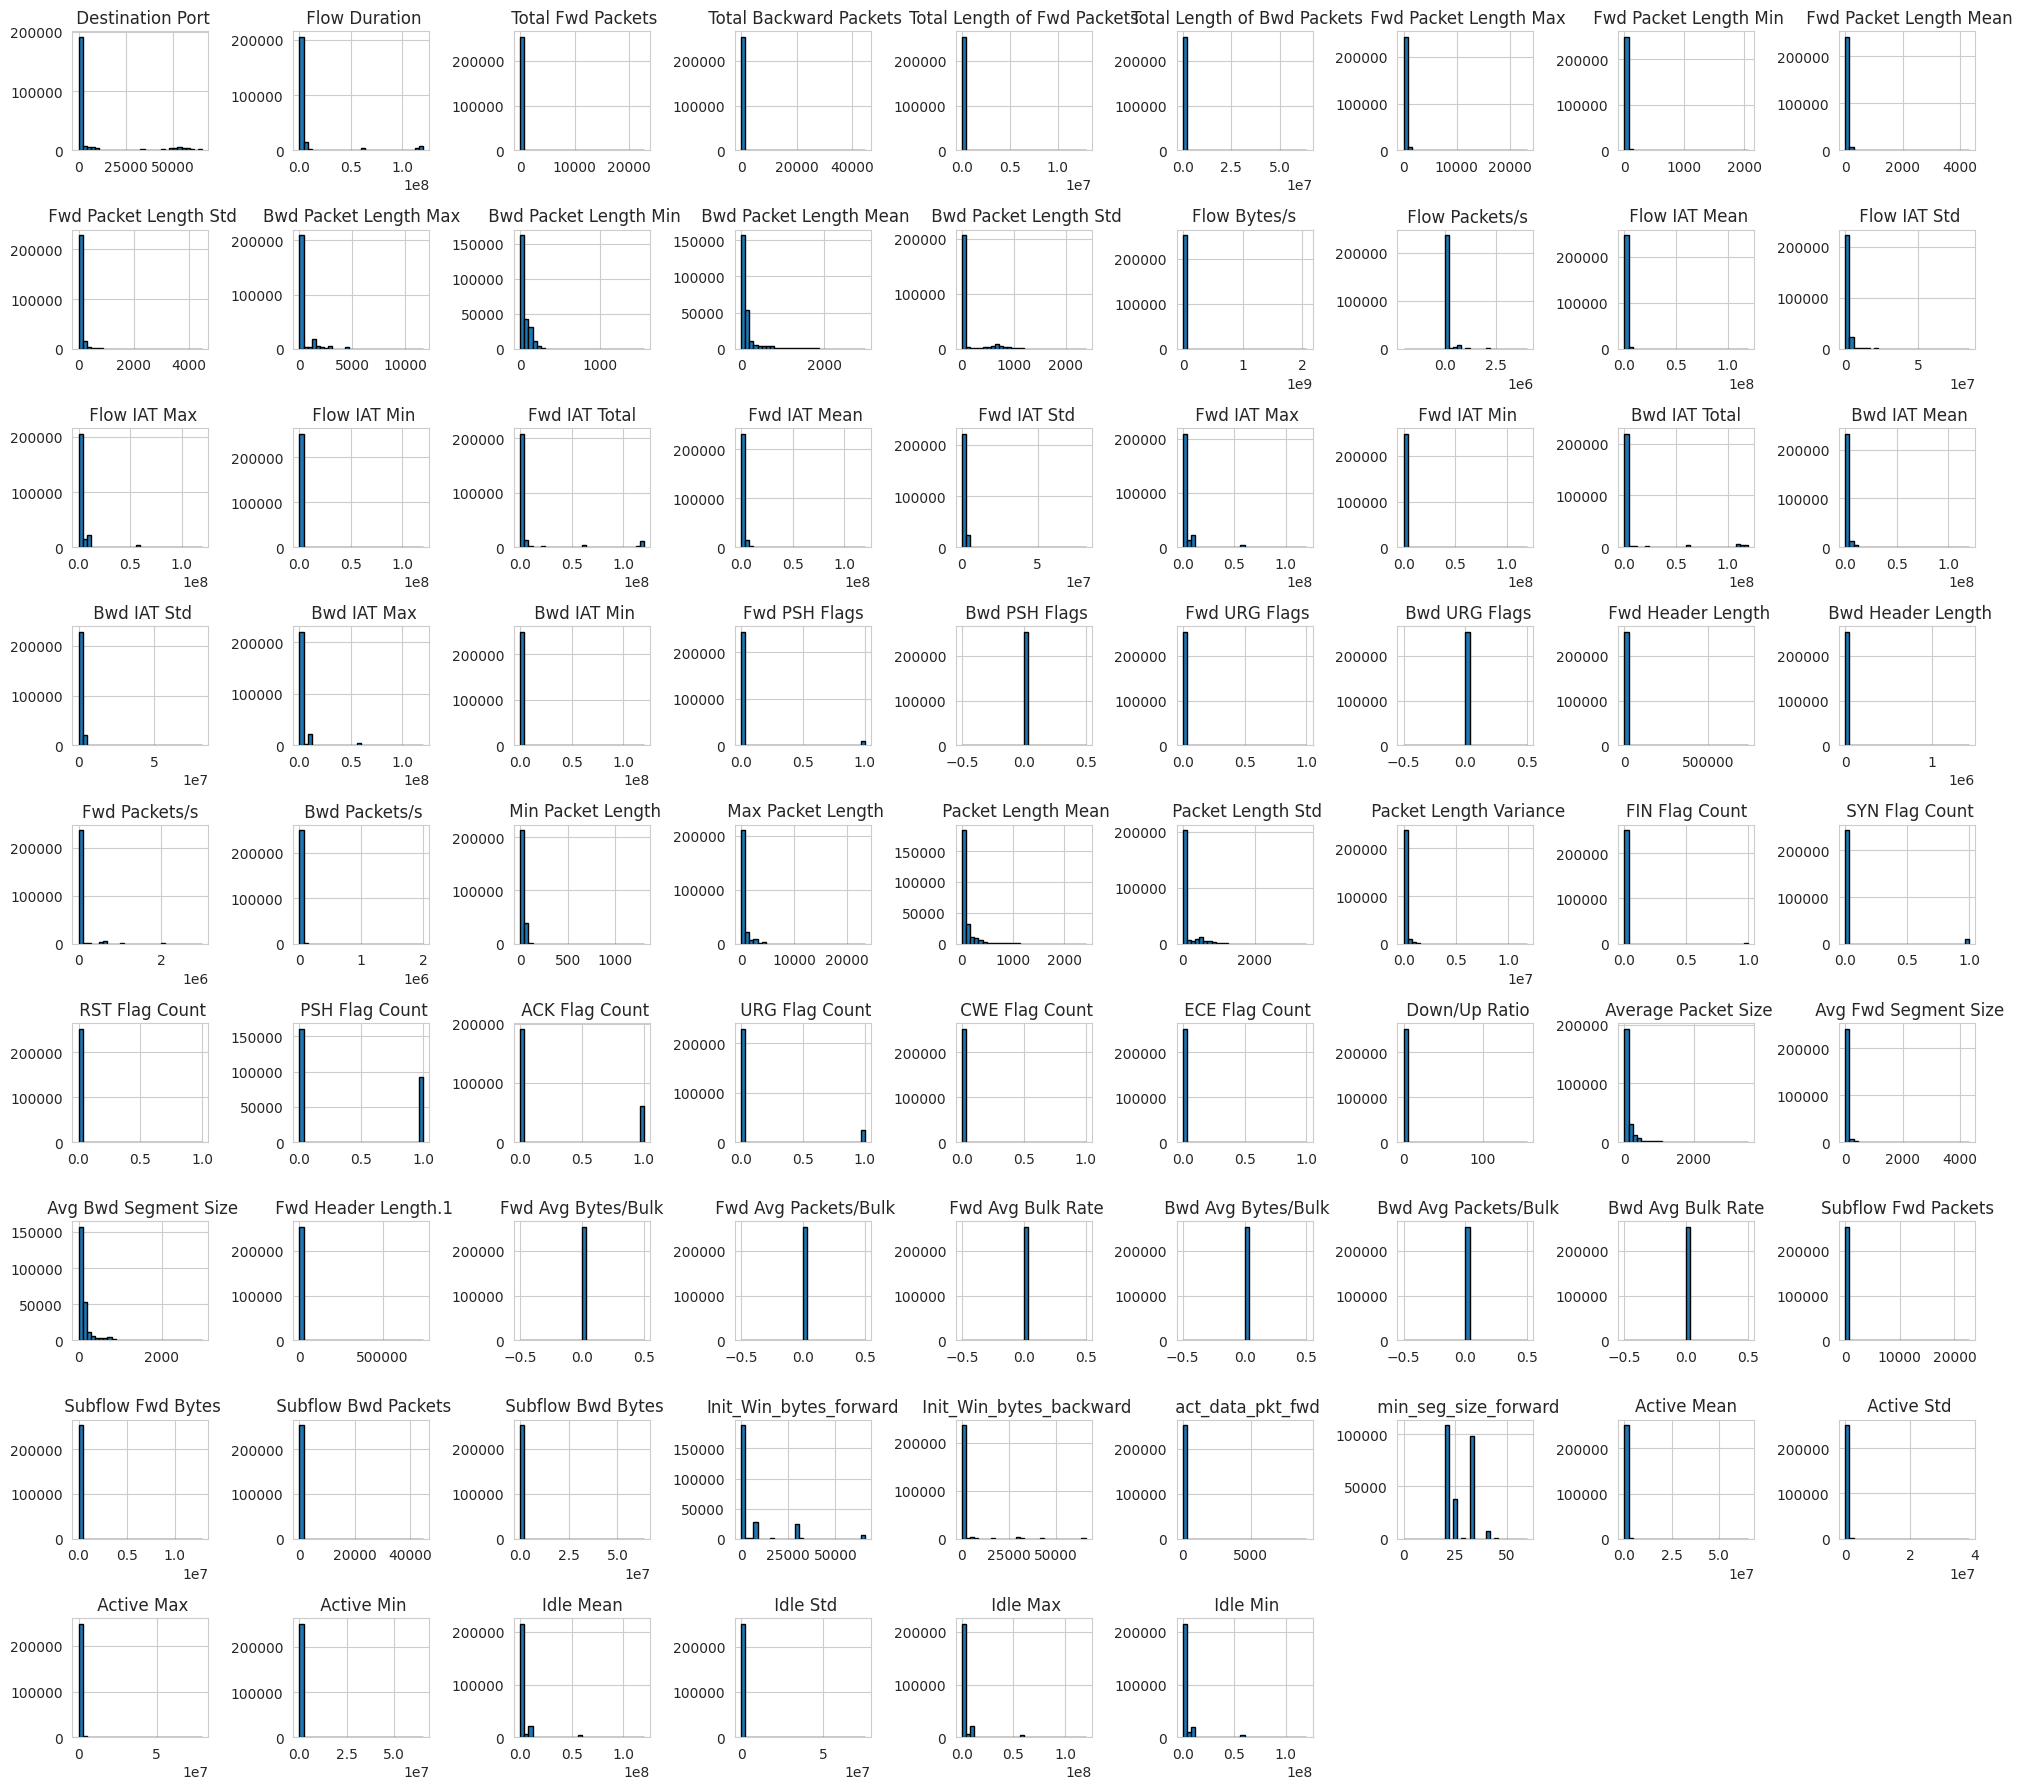


Generating Correlation Heatmap...


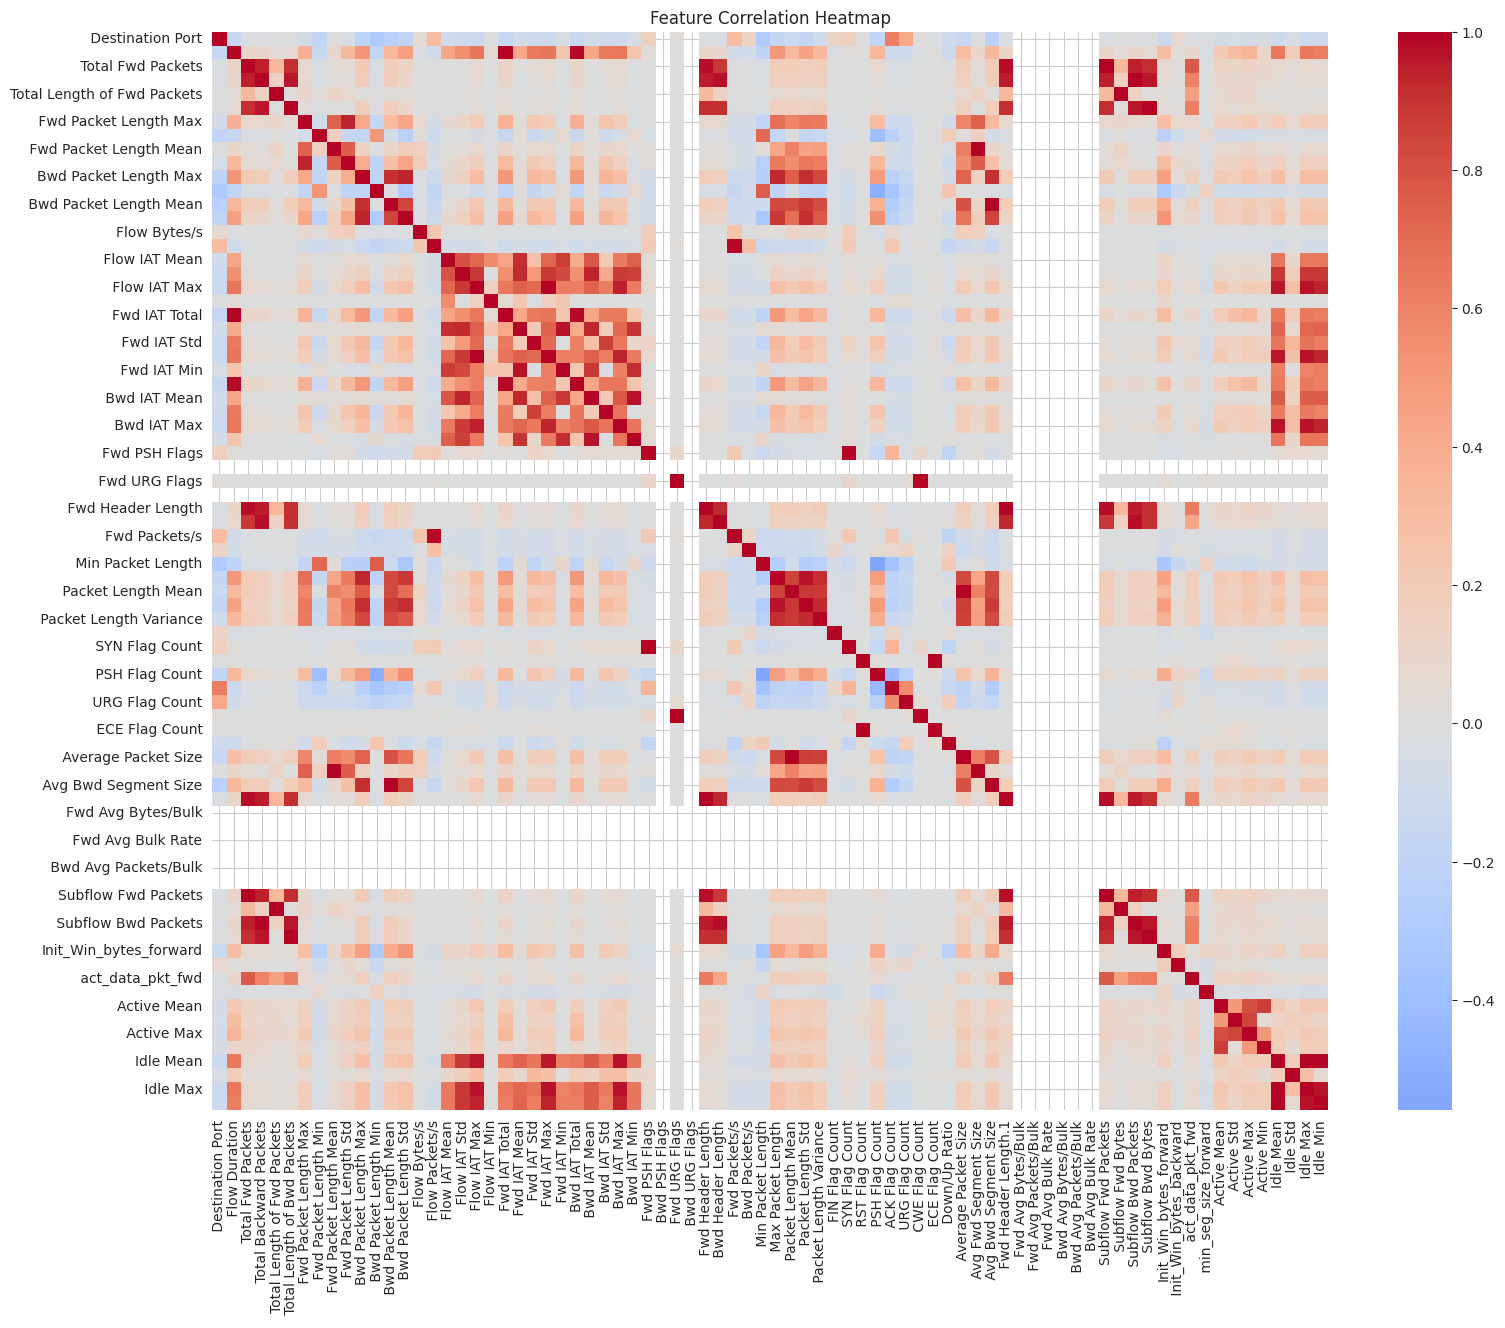


Generating Boxplots...


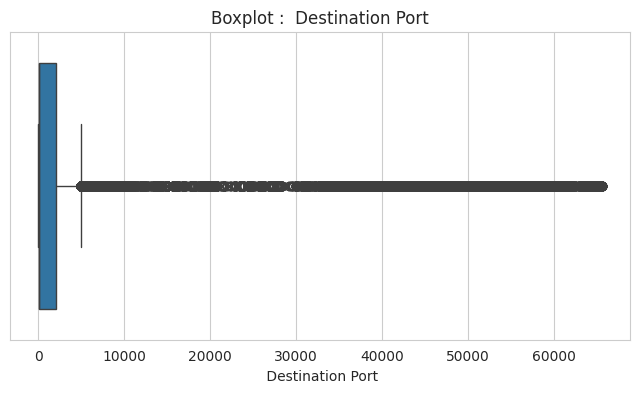

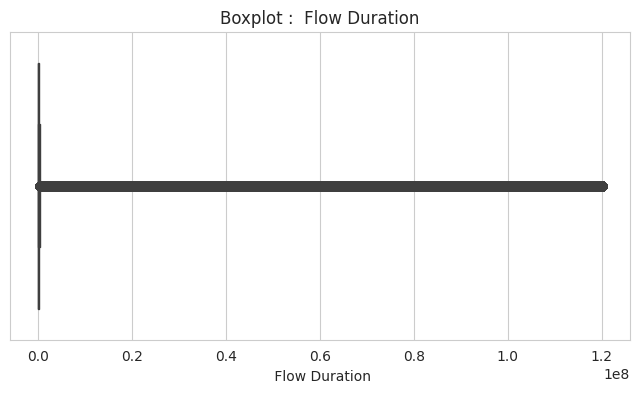

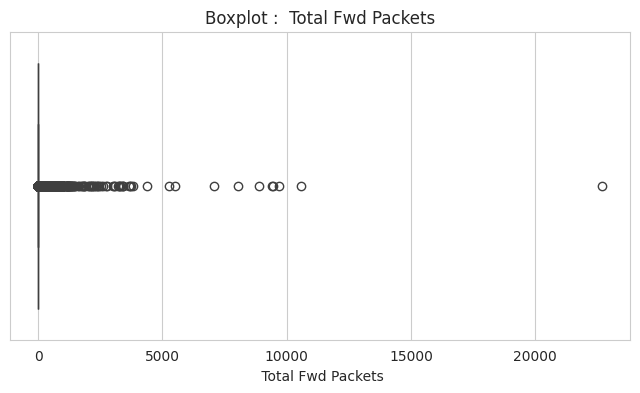

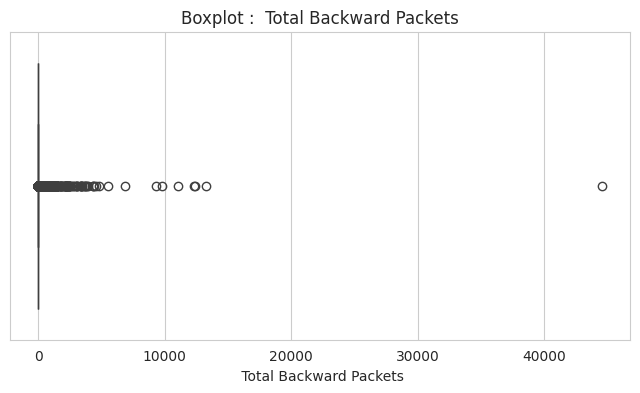

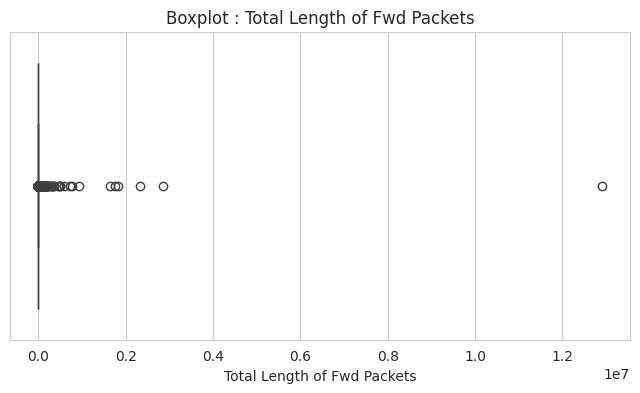

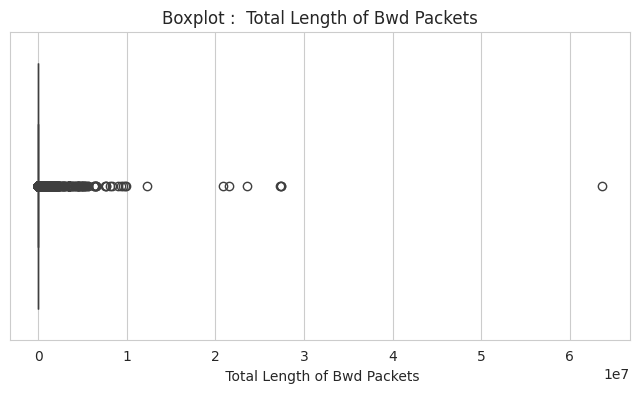

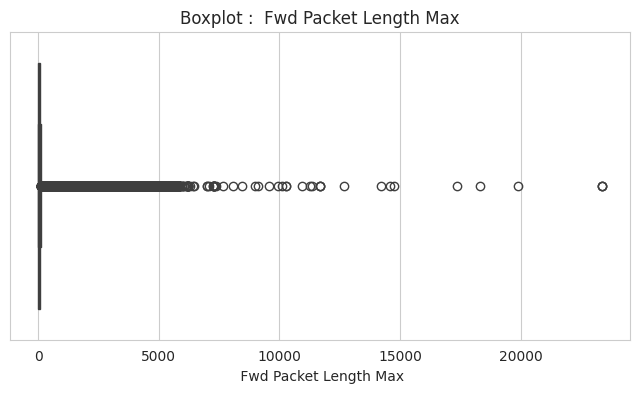

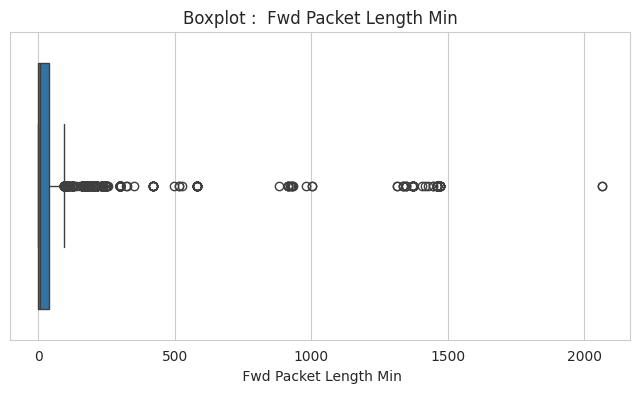

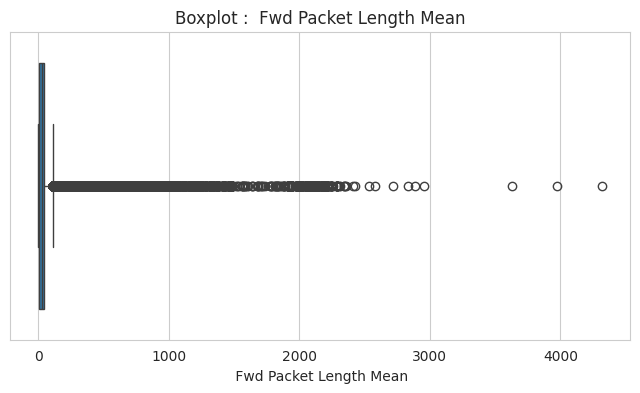

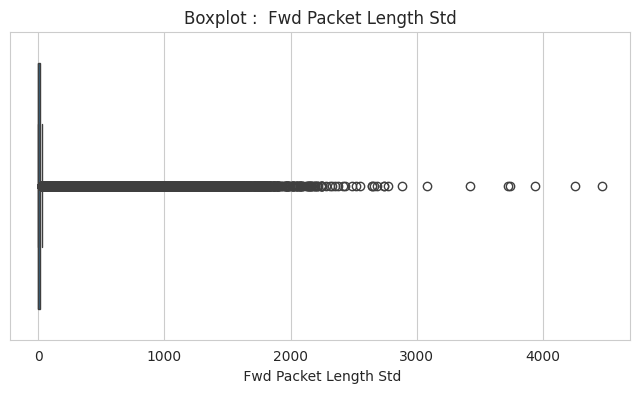

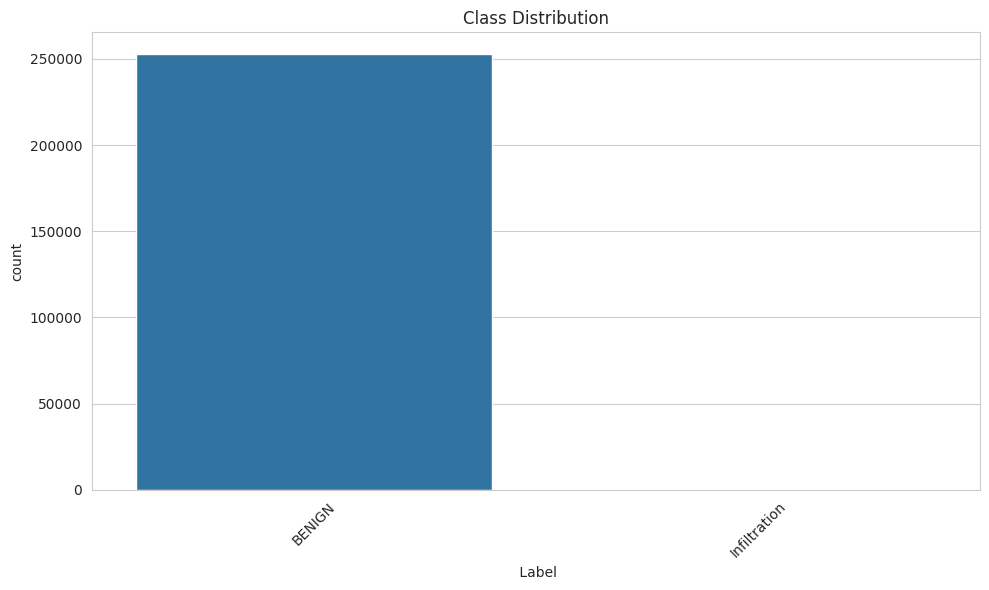

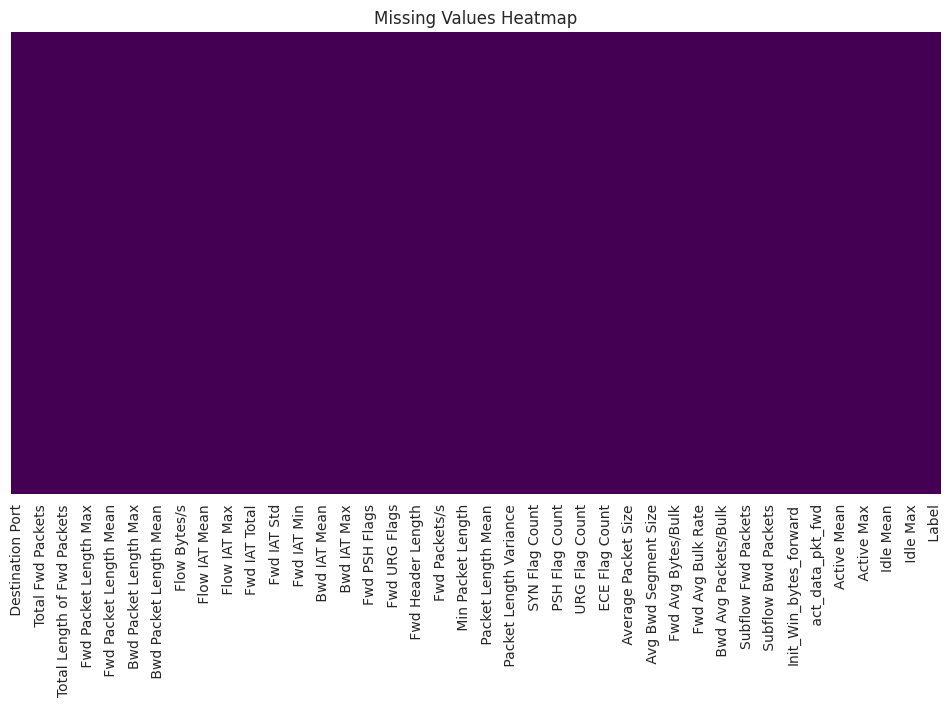

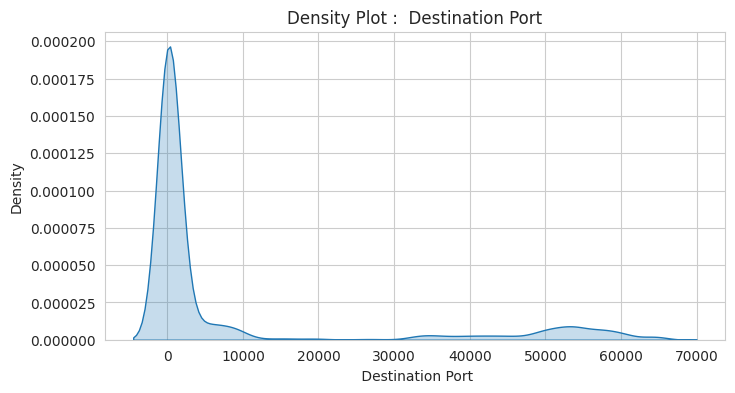

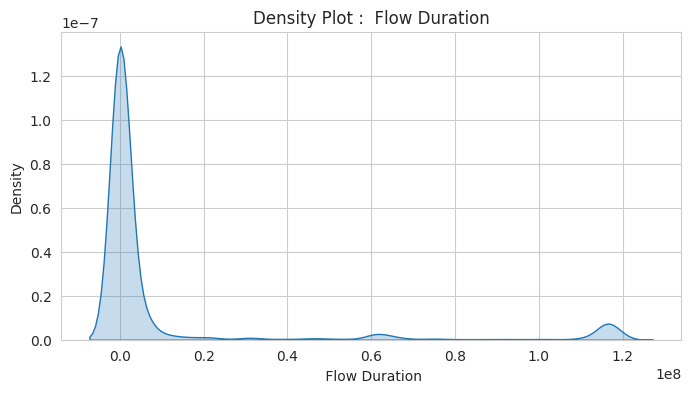

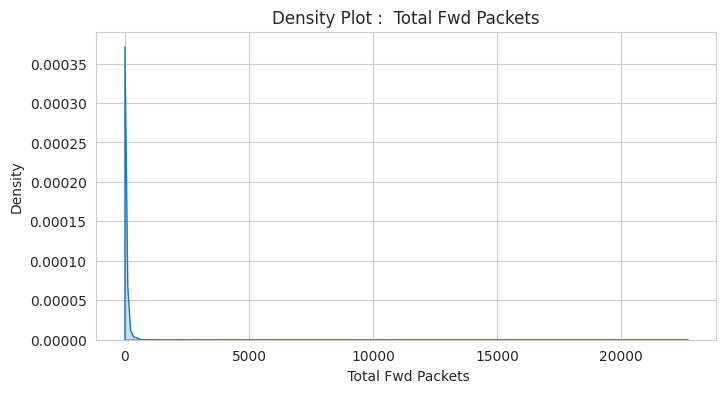

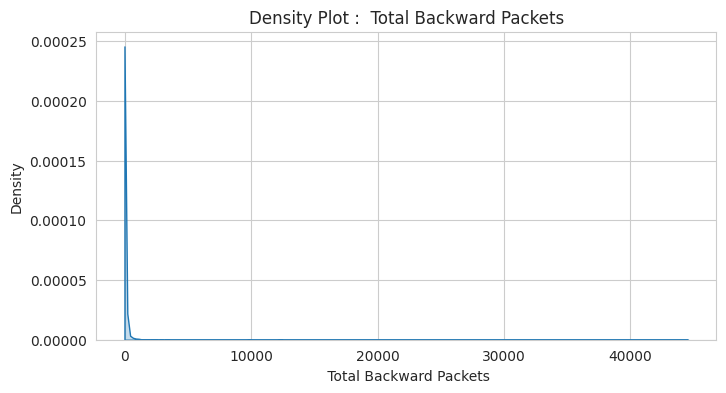

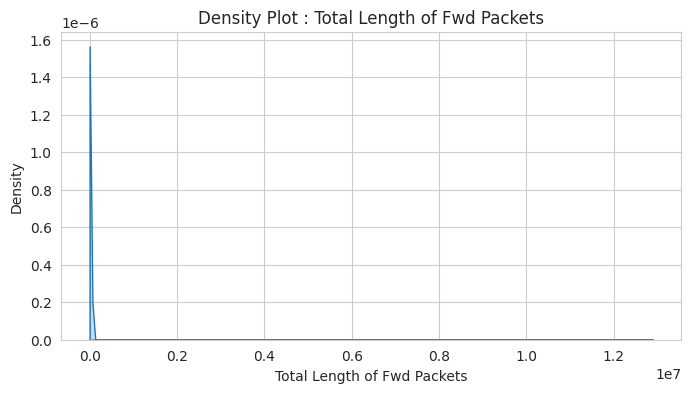

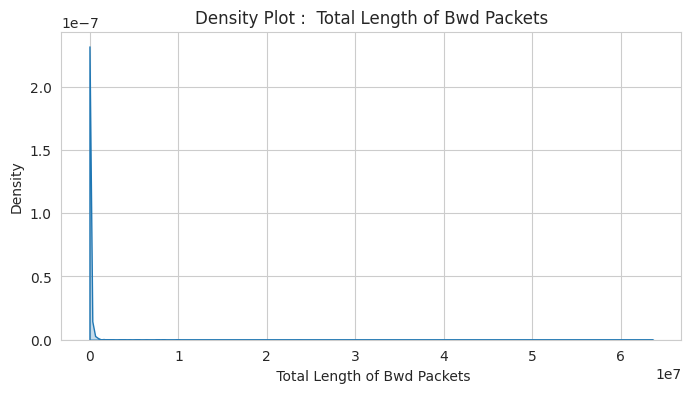

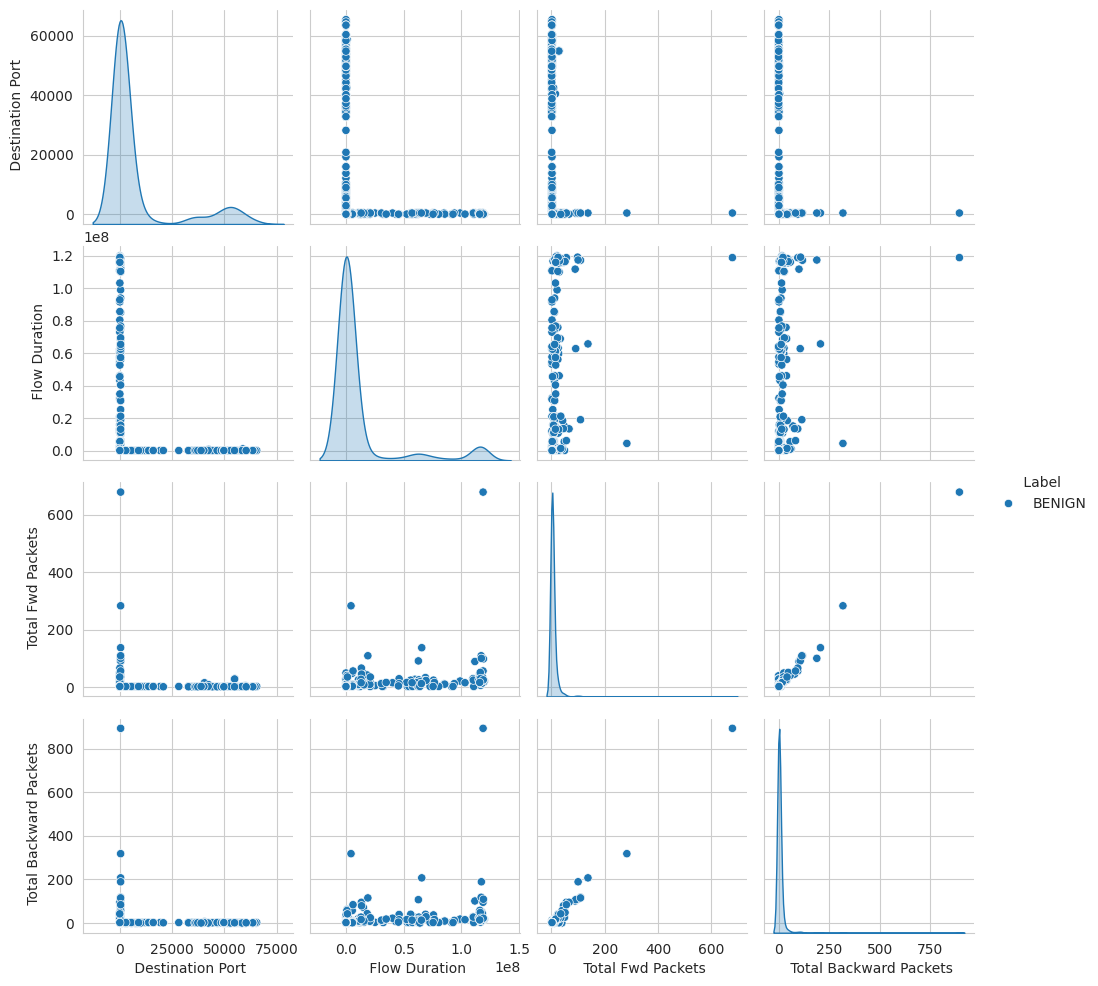


EDA Completed Successfully


In [17]:
# ==========================================================
# Module 3 : Exploratory Data Analysis
# ==========================================================

# Load the Cleaned Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

print("="*60)
print("Loading Cleaned Dataset")
print("="*60)

df = pd.read_csv("data.csv")

print("Dataset Loaded Successfully")
print(df.shape)

# Basic Dataset Information
print("\nDataset Information\n")

print(df.info())

print("\nStatistical Summary\n")

print(df.describe())

# Histograms :This visualizes the distribution of all numeric features.
print("\nGenerating Histograms...")

numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(20,18),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()

plt.savefig("Histogram_All_Features.png")

plt.show()

# Correlation Heatmap :This is one of the most important EDA figures.
print("\nGenerating Correlation Heatmap...")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.savefig("Correlation_Heatmap.png")

plt.show()

# Boxplots (Outlier Detection) :Instead of plotting every feature (which becomes unreadable with 80+ columns), we'll display the first 10 numeric features.
print("\nGenerating Boxplots...")

features = numeric_columns[:10]

for feature in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[feature])

    plt.title(f"Boxplot : {feature}")

    plt.savefig(f"Boxplot_{feature}.png")

    plt.show()

# Class Distribution : Understanding class imbalance is essential.
TARGET = " Label"

if TARGET in df.columns:

    plt.figure(figsize=(10,6))

    sns.countplot(
        x=df[TARGET],
        order=df[TARGET].value_counts().index
    )

    plt.xticks(rotation=45)

    plt.title("Class Distribution")

    plt.tight_layout()

    plt.savefig("Class_Distribution.png")

    plt.show()

else:

    print("Target column not found.")

# Missing Values Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.savefig("Missing_Values.png")

plt.show()

# Feature Density Plots : Density plots provide a smoother view than histograms.
features = numeric_columns[:6]

for feature in features:

    plt.figure(figsize=(8,4))

    sns.kdeplot(df[feature], fill=True)

    plt.title(f"Density Plot : {feature}")

    plt.savefig(f"Density_{feature}.png")

    plt.show()

# Pair Plot : Pair plots become prohibitively expensive for large datasets. We'll sample a subset.
sample = df.sample(
    n=min(1000, len(df)),
    random_state=42
)

selected = list(numeric_columns[:4])

if " Label" in df.columns:
    selected.append(" Label")

sns.pairplot(
    sample[selected],
    hue=" Label" if " Label" in sample.columns else None
)

plt.savefig("PairPlot.png")

plt.show()

# Save Correlation Matrix
corr.to_csv("Correlation_Matrix.csv", index=True)

# Module 3 completion
print("\nEDA Completed Successfully")

In [18]:
# ==========================================================
# Module 4: Train Machine Learning Models
# ==========================================================

import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Machine Learning Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import ExtraTreesClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.neural_network import MLPClassifier

# Load Dataset

print("="*60)
print("Loading Cleaned Dataset")
print("="*60)

df = pd.read_csv("data.csv")

print(df.shape)

# Separate Features and Target

TARGET = " Label"

X = df.drop(TARGET, axis=1)

y = df[TARGET]


# Encode Target Labels

encoder = LabelEncoder()

y = encoder.fit_transform(y)


# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("\nTraining Samples :", X_train.shape[0])

print("Testing Samples  :", X_test.shape[0])


# Feature Scaling

schalar = StandardScaler()

X_train_scaled = schalar.fit_transform(X_train)

X_test_scaled = schalar.transform(X_test)


# Define Models

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=100,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(),

    "Support Vector Machine":
        SVC(),

    "Neural Network":
        MLPClassifier(
            hidden_layer_sizes=(100,),
            max_iter=300,
            random_state=42
        )

}

# Train Models

trained_models = {}

print("\nTraining Models...\n")

for name, model in models.items():

    print(f"Training {name}...")

    # Models that require scaling

    if name in [

        "Logistic Regression",

        "KNN",

        "Support Vector Machine",

        "Neural Network"

    ]:

        model.fit(X_train_scaled, y_train)

    else:

        model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} Completed\n")

print("="*60)

print("All Models Trained Successfully")

print("="*60)

Loading Cleaned Dataset
(252790, 79)

Training Samples : 202232
Testing Samples  : 50558

Training Models...

Training Logistic Regression...
Logistic Regression Completed

Training Decision Tree...
Decision Tree Completed

Training Random Forest...
Random Forest Completed

Training Extra Trees...
Extra Trees Completed

Training KNN...
KNN Completed

Training Support Vector Machine...
Support Vector Machine Completed

Training Neural Network...
Neural Network Completed

All Models Trained Successfully


In [19]:
# ==========================================================
# Module 5 : Evaluate Machine Learning Models
# ==========================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("="*60)
print("Evaluating Models...")
print("="*60)

results = {}

for name, model in trained_models.items():

    print(f"Evaluating {name}...")

    # Models that were scaled for training need scaled test data
    if name in [
        "Logistic Regression",
        "KNN",
        "Support Vector Machine",
        "Neural Network"
    ]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }
    print(f"{name} Evaluation Completed.\n")

print("="*60)
print("Model Evaluation Summary")
print("="*60)

results_df = pd.DataFrame(results).T
print(results_df.round(4))

print("\nModule 5 Completed Successfully")

Evaluating Models...
Evaluating Logistic Regression...
Logistic Regression Evaluation Completed.

Evaluating Decision Tree...
Decision Tree Evaluation Completed.

Evaluating Random Forest...
Random Forest Evaluation Completed.

Evaluating Extra Trees...
Extra Trees Evaluation Completed.

Evaluating KNN...
KNN Evaluation Completed.

Evaluating Support Vector Machine...
Support Vector Machine Evaluation Completed.

Evaluating Neural Network...
Neural Network Evaluation Completed.

Model Evaluation Summary
                        Accuracy  Precision  Recall  F1-Score
Logistic Regression       0.9999     0.9999  0.9999    0.9999
Decision Tree             0.9999     0.9999  0.9999    0.9999
Random Forest             0.9999     0.9999  0.9999    0.9999
Extra Trees               0.9999     0.9999  0.9999    0.9999
KNN                       0.9999     0.9997  0.9999    0.9998
Support Vector Machine    0.9999     0.9997  0.9999    0.9998
Neural Network            0.9999     0.9999  0.9999    0.

In [23]:
# ==========================================================
# Module 6 : Save Best Model
# ==========================================================

import pandas as pd
import pickle
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# NOTE: No specific model import needed here as we will load the best model from trained_models


# Load Cleaned Dataset
print("="*60)
print("Loading Dataset")
print("="*60)

df = pd.read_csv(
    "data.csv"
)

# Separate Features and Target
TARGET = " Label"

X = df.drop(
    TARGET,
    axis=1
)
y = df[TARGET]

# Encode Labels
encoder = LabelEncoder()
y = encoder.fit_transform(
    y
)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Select the best model based on evaluation results from Module 5
# Assuming results_df and trained_models are available from previous cells' execution

if 'results_df' in globals() and 'trained_models' in globals():
    best_model_name = results_df['Accuracy'].idxmax()
    best_model = trained_models[best_model_name]
    print(f"\nSelected best model: {best_model_name} with Accuracy: {results_df['Accuracy'].max():.4f}")
else:
    print("Warning: 'results_df' or 'trained_models' not found. Defaulting to a new RandomForestClassifier.")
    best_model_name = "RandomForestClassifier (Default)"
    best_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

print(f"\nTraining Final Model ({best_model_name})...")

# Models that require scaling for training
# This logic should ideally match what was done in Module 4 for consistency
if best_model_name in [
    "Logistic Regression",
    "KNN",
    "Support Vector Machine",
    "Neural Network"
]:
    # Assuming X_train_scaled is available from Module 4
    if 'X_train_scaled' in globals():
        best_model.fit(X_train_scaled, y_train)
    else:
        print("Error: X_train_scaled not found for scaled model. Training with unscaled data.")
        best_model.fit(X_train, y_train)
else:
    best_model.fit(X_train, y_train)

print("Training Completed")

# Save Model using Pickle
print("\nSaving Model...")
pickle.dump(
    best_model,
    open(
        "model.pkl",
        "wb"
            )
)
print("Model saved successfully")


# Save Label Encoder
pickle.dump(
    encoder,
    open(
        "label_encoder.pkl",
        "wb"    )
)
print("Label encoder saved")


# Save Feature Names
pickle.dump(
    list(X.columns),
    open(
        "features.pkl",
        "wb"
    )
)
print("Feature list saved")

# Verify Saved Files
print("\nSaved Files:")
for file in [
    "model.pkl",
    "label_encoder.pkl",
    "features.pkl"

]:
    if os.path.exists(file):
        print(
            f"✓ {file}"
        )
    else:
        print(
            f"✗ {file} missing"
        )
print("\n")
print("="*60)
print("MODEL SAVING COMPLETED")
print("="*60)


Loading Dataset

Selected best model: Extra Trees with Accuracy: 0.9999

Training Final Model (Extra Trees)...
Training Completed

Saving Model...
Model saved successfully
Label encoder saved
Feature list saved

Saved Files:
✓ model.pkl
✓ label_encoder.pkl
✓ features.pkl


MODEL SAVING COMPLETED


In [1]:
%%writefile requirements.txt
pandas
scikit-learn
streamlit
matplotlib
seaborn
numpy

Writing requirements.txt


In [4]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 106.6 MB/s eta 0:00:00


In [9]:
%%writefile app.py
#==================
# app.py
#==================

import streamlit as st
import pandas as pd
import pickle
import os

# Imports for EDA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

st.set_page_config(layout="wide")

st.title("Network Intrusion Detection")
st.write("This application predicts network intrusion based on flow features.")

# Load the model, label encoder, and features
@st.cache_resource
def load_artifacts():
    try:
        model = pickle.load(open('model.pkl', 'rb'))
        label_encoder = pickle.load(open('label_encoder.pkl', 'rb'))
        features = pickle.load(open('features.pkl', 'rb'))
        return model, label_encoder, features
    except FileNotFoundError as e:
        st.error(f"Error loading necessary files: {e}. Make sure 'model.pkl', 'label_encoder.pkl', and 'features.pkl' are in the same directory.")
        st.stop()

model, label_encoder, features = load_artifacts()

st.sidebar.header("Input Features")

# Create input fields for each feature
input_data = {}
for feature in features:
    # Attempt to infer type for better input widgets
    if 'Flow Duration' in feature or 'Packet Length' in feature or 'IAT' in feature or 'Bytes/s' in feature:
        input_data[feature] = st.sidebar.number_input(f"Enter {feature}", value=0.0)
    elif 'Port' in feature or 'Packets' in feature or 'seg_size' in feature:
        input_data[feature] = st.sidebar.number_input(f"Enter {feature}", value=0, format="%d")
    elif 'Std' in feature or 'Mean' in feature or 'Min' in feature or 'Max' in feature:
        input_data[feature] = st.sidebar.number_input(f"Enter {feature}", value=0.0)
    elif 'Flag' in feature:
        input_data[feature] = st.sidebar.selectbox(f"Select {feature}", [0, 1])
    else:
        input_data[feature] = st.sidebar.text_input(f"Enter {feature}", value="0") # Default to text for unknown types

# Convert input data to DataFrame
input_df = pd.DataFrame([input_data])

# Preprocess input data (e.g., scaling if the model was trained on scaled data)
# NOTE: If your best model (Extra Trees) was trained on unscaled data, you don't need scaling here.
# If you switch to a scaled model (e.g., Logistic Regression), you would need to implement StandardScaler here.

if st.button("Predict"):
    try:
        prediction_encoded = model.predict(input_df)
        prediction_label = label_encoder.inverse_transform(prediction_encoded)

        st.success(f"The predicted class is: **{prediction_label[0]}**")

        st.subheader("Raw Prediction Output")
        st.write(prediction_encoded)

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")
        st.write("Please check your input values and ensure they are numerical where expected.")

# --- EDA Section ---
st.subheader("Exploratory Data Analysis (Optional)")
with st.expander("View Data Overview and Distributions"):
    st.write("Here are some key visualizations from the initial data exploration of `data.csv`:")

    # Load the original data for EDA
    @st.cache_data
    def load_eda_data():
        try:
            return pd.read_csv("data.csv")
        except FileNotFoundError:
            st.error("Error: 'data.csv' not found for EDA. Please ensure it's in the same directory for visualizations.")
            st.stop()

    eda_df = load_eda_data()

    if eda_df is not None:
        # Class Distribution
        st.write("#### Class Distribution")
        TARGET_COLUMN_EDA = " Label" # Ensure this matches the column name in data.csv
        if TARGET_COLUMN_EDA in eda_df.columns:
            fig_class_dist = plt.figure(figsize=(8, 5))
            sns.countplot(x=eda_df[TARGET_COLUMN_EDA], order=eda_df[TARGET_COLUMN_EDA].value_counts().index)
            plt.xticks(rotation=45)
            plt.title("Class Distribution")
            plt.tight_layout()
            st.pyplot(fig_class_dist)
            plt.close(fig_class_dist) # Close figure to free memory
        else:
            st.warning(f"Target column '{TARGET_COLUMN_EDA}' not found in data.csv for class distribution.")

        # Correlation Heatmap
        st.write("#### Feature Correlation Heatmap (Numeric Features)")
        numeric_columns_eda = eda_df.select_dtypes(include=np.number).columns
        if not numeric_columns_eda.empty:
            corr_eda = eda_df[numeric_columns_eda].corr()

            fig_heatmap = plt.figure(figsize=(15, 12))
            sns.heatmap(corr_eda, cmap="coolwarm", center=0, annot=False, fmt=".2f")
            plt.title("Feature Correlation Heatmap")
            st.pyplot(fig_heatmap)
            plt.close(fig_heatmap)
        else:
            st.info("No numeric columns found for correlation heatmap.")

        # Example Feature Histograms (First 5 Numeric Features)
        st.write("#### Example Feature Histograms (First 5 Numeric Features)")
        example_features = numeric_columns_eda[:5]
        if not example_features.empty:
            for feature in example_features:
                fig_hist = plt.figure(figsize=(7, 4))
                sns.histplot(eda_df[feature], kde=True)
                plt.title(f"Histogram: {feature}")
                st.pyplot(fig_hist)
                plt.close(fig_hist)
        else:
            st.info("No numeric columns found to plot example histograms.")

Overwriting app.py
